# 04: Spatial Analysis

**Goal**: Analyze spatial patterns in transit accessibility to understand clustering, autocorrelation, and relationships with demographics.

**What We'll Do**:
1. Load accessibility and demographic data from Notebook 03
2. Exploratory spatial analysis (maps, scatter plots)
3. Spatial autocorrelation (Global and Local Moran's I)
4. Spatial clustering analysis
5. Spatial regression models (OLS, Spatial Lag, Spatial Error)
6. Visualizations of spatial patterns

**Outputs**:
- `outputs/spatial_autocorrelation_results.csv` - Moran's I statistics
- `outputs/spatial_regression_results.csv` - Regression coefficients
- Visualizations: spatial autocorrelation maps, regression diagnostics, cluster maps


In [10]:
from pathlib import Path
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Spatial analysis libraries
try:
    from libpysal.weights import Queen, Rook, KNN
    from esda.moran import Moran, Moran_Local
    from spreg import OLS, ML_Lag, ML_Error
    print("✓ Spatial analysis libraries loaded")
except ImportError:
    print("⚠ libpysal not found. Install with: pip install libpysal esda spreg")
    raise

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

ROOT = Path("/Users/aaryakhanna/transit-deserts").resolve()
os.chdir(ROOT)

data_raw = ROOT / "data_raw"
outputs = ROOT / "outputs"

print("✓ Imports loaded")
print(f"Working directory: {ROOT}")


✓ Spatial analysis libraries loaded
✓ Imports loaded
Working directory: /Users/aaryakhanna/transit-deserts


## Step 1: Load Data

Load tracts with accessibility metrics and demographics from Notebook 03.


In [11]:
# Load tracts with accessibility data
print("Loading data from Notebook 03...")

tracts_access = gpd.read_file(outputs / "tracts_with_accessibility.geojson")
tracts_access['GEOID'] = tracts_access['GEOID'].astype(str)

# Clean income data (replace Census missing code with NaN)
tracts_access['median_income'] = tracts_access['median_income'].replace(-666666666, np.nan)

# Use 30-minute accessibility as primary measure
access_col = 'access_30min_per1k'

# Clean accessibility data (remove infinite values)
tracts_access[access_col] = tracts_access[access_col].replace([np.inf, -np.inf], np.nan)
tracts_access[access_col] = tracts_access[access_col].fillna(0)

# Filter to tracts with valid data
tracts_analysis = tracts_access[
    tracts_access[access_col].notna() & 
    tracts_access['pop_total'].notna() & 
    (tracts_access['pop_total'] > 0)
].copy()

print(f"✓ Loaded {len(tracts_analysis):,} tracts with valid data")
print(f"  Tracts with accessibility data: {tracts_analysis[access_col].notna().sum():,}")
print(f"  Mean accessibility: {tracts_analysis[access_col].mean():.1f} jobs/1k")
print(f"  Median accessibility: {tracts_analysis[access_col].median():.1f} jobs/1k")


Loading data from Notebook 03...
✓ Loaded 2,476 tracts with valid data
  Tracts with accessibility data: 2,476
  Mean accessibility: 76355.5 jobs/1k
  Median accessibility: 0.0 jobs/1k


## Step 2: Exploratory Spatial Analysis

Create exploratory visualizations to understand spatial patterns.


Creating exploratory scatter plots...
✓ Saved exploratory plots to outputs/spatial_exploratory_analysis.png


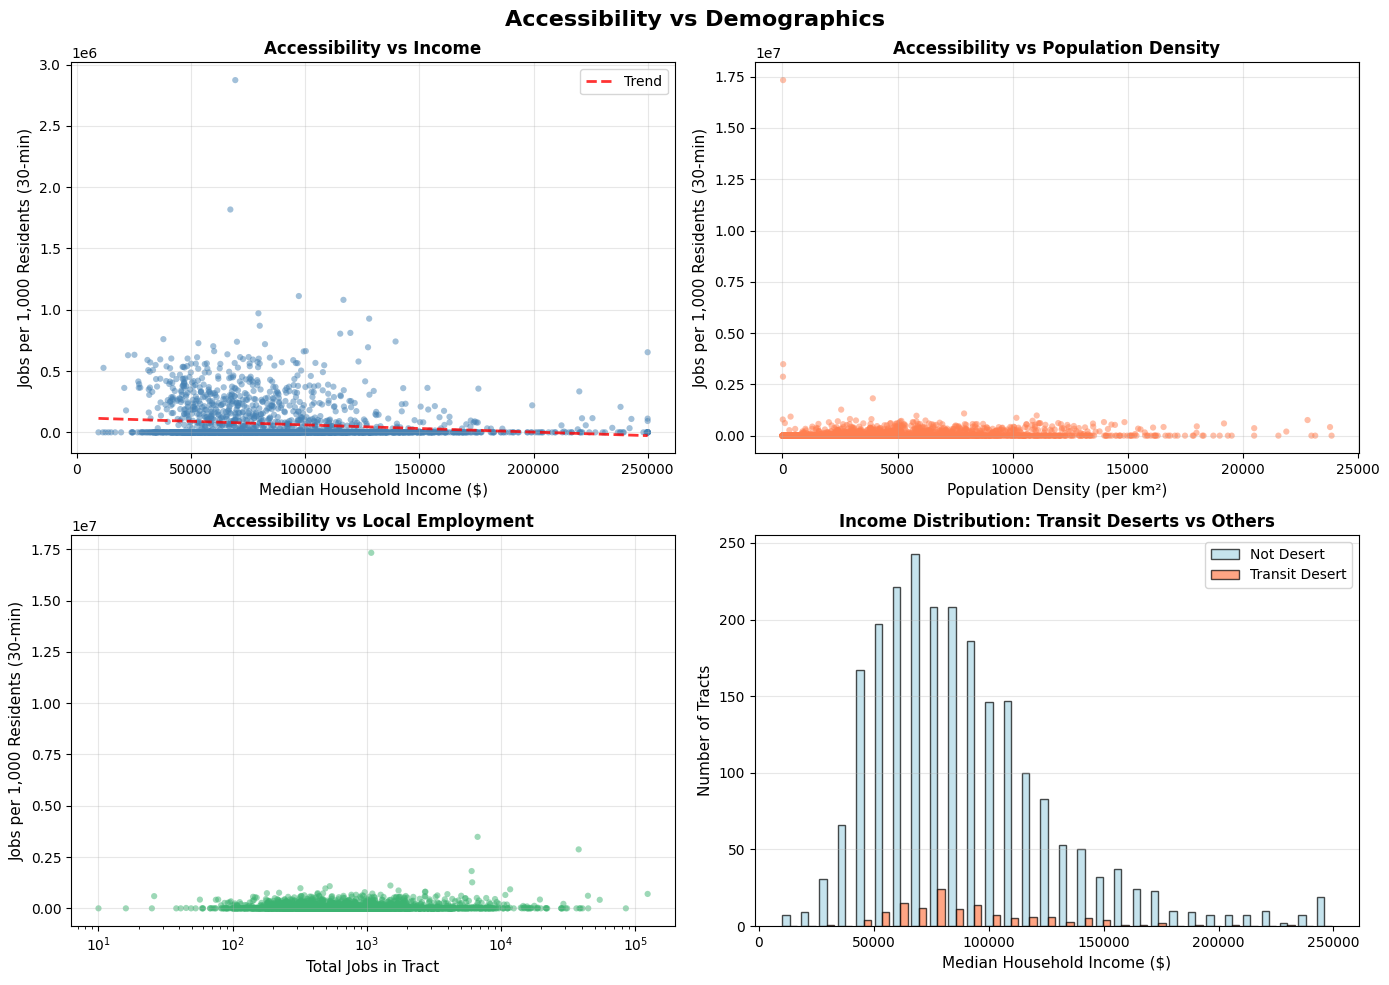


📊 VISUALIZATION EXPLANATION: Exploratory Scatter Plots

1. Accessibility vs Income (top-left):
   - Shows relationship between household income and transit accessibility
   - Negative trend = lower-income areas have better transit access (equity concern)
   - Positive trend = higher-income areas have better transit access (expected)

2. Accessibility vs Population Density (top-right):
   - Tests if denser areas have better transit access
   - Higher density should correlate with better transit (transit-oriented development)

3. Accessibility vs Local Employment (bottom-left):
   - Shows if tracts with more jobs have better transit access
   - Log scale because job counts vary widely

4. Income Distribution: Transit Deserts vs Others (bottom-right):
   - Compares income levels between transit deserts and non-deserts
   - If deserts have lower income, this confirms equity concerns


In [12]:
# Visualization 1: Accessibility vs Demographics (scatter plots)
print("Creating exploratory scatter plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Accessibility vs Demographics', fontsize=16, fontweight='bold')

# 1. Accessibility vs Income
income_data = tracts_analysis[[access_col, 'median_income']].dropna()
if len(income_data) > 0:
    axes[0, 0].scatter(income_data['median_income'], income_data[access_col], 
                       alpha=0.5, s=20, c='steelblue', edgecolors='none')
    axes[0, 0].set_xlabel('Median Household Income ($)', fontsize=11)
    axes[0, 0].set_ylabel('Jobs per 1,000 Residents (30-min)', fontsize=11)
    axes[0, 0].set_title('Accessibility vs Income', fontsize=12, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)
    
    # Add trend line
    if len(income_data) > 2:
        z = np.polyfit(income_data['median_income'], income_data[access_col], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(income_data['median_income'].min(), 
                             income_data['median_income'].max(), 100)
        axes[0, 0].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend')
        axes[0, 0].legend()

# 2. Accessibility vs Population Density
# FIX: Project to UTM before calculating area (to get accurate km²)
tracts_proj_temp = tracts_analysis.to_crs('EPSG:32611')  # UTM Zone 11N (meters)
tracts_analysis['pop_density'] = tracts_analysis['pop_total'] / (tracts_proj_temp.geometry.area / 1_000_000)  # per km²
pop_density_data = tracts_analysis[[access_col, 'pop_density']].dropna()
pop_density_data = pop_density_data[pop_density_data['pop_density'] < pop_density_data['pop_density'].quantile(0.99)]  # Remove outliers

if len(pop_density_data) > 0:
    axes[0, 1].scatter(pop_density_data['pop_density'], pop_density_data[access_col], 
                       alpha=0.5, s=20, c='coral', edgecolors='none')
    axes[0, 1].set_xlabel('Population Density (per km²)', fontsize=11)
    axes[0, 1].set_ylabel('Jobs per 1,000 Residents (30-min)', fontsize=11)
    axes[0, 1].set_title('Accessibility vs Population Density', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)

# 3. Accessibility vs Jobs (employment density)
jobs_data = tracts_analysis[[access_col, 'jobs_total']].dropna()
jobs_data = jobs_data[jobs_data['jobs_total'] > 0]
if len(jobs_data) > 0:
    axes[1, 0].scatter(jobs_data['jobs_total'], jobs_data[access_col], 
                       alpha=0.5, s=20, c='mediumseagreen', edgecolors='none')
    axes[1, 0].set_xlabel('Total Jobs in Tract', fontsize=11)
    axes[1, 0].set_ylabel('Jobs per 1,000 Residents (30-min)', fontsize=11)
    axes[1, 0].set_title('Accessibility vs Local Employment', fontsize=12, fontweight='bold')
    axes[1, 0].set_xscale('log')
    axes[1, 0].grid(alpha=0.3)

# 4. Transit desert classification by income
if 'transit_desert' in tracts_analysis.columns:
    desert_income = tracts_analysis[tracts_analysis['transit_desert'] == True]['median_income'].dropna()
    non_desert_income = tracts_analysis[tracts_analysis['transit_desert'] == False]['median_income'].dropna()
    
    if len(desert_income) > 0 and len(non_desert_income) > 0:
        axes[1, 1].hist([non_desert_income, desert_income], bins=30, 
                        label=['Not Desert', 'Transit Desert'], 
                        alpha=0.7, color=['lightblue', 'coral'], edgecolor='black')
        axes[1, 1].set_xlabel('Median Household Income ($)', fontsize=11)
        axes[1, 1].set_ylabel('Number of Tracts', fontsize=11)
        axes[1, 1].set_title('Income Distribution: Transit Deserts vs Others', fontsize=12, fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plot_path = outputs / "spatial_exploratory_analysis.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved exploratory plots to {plot_path.relative_to(ROOT)}")
plt.show()

print("\n" + "="*70)
print("📊 VISUALIZATION EXPLANATION: Exploratory Scatter Plots")
print("="*70)
print("\n1. Accessibility vs Income (top-left):")
print("   - Shows relationship between household income and transit accessibility")
print("   - Negative trend = lower-income areas have better transit access (equity concern)")
print("   - Positive trend = higher-income areas have better transit access (expected)")
print("\n2. Accessibility vs Population Density (top-right):")
print("   - Tests if denser areas have better transit access")
print("   - Higher density should correlate with better transit (transit-oriented development)")
print("\n3. Accessibility vs Local Employment (bottom-left):")
print("   - Shows if tracts with more jobs have better transit access")
print("   - Log scale because job counts vary widely")
print("\n4. Income Distribution: Transit Deserts vs Others (bottom-right):")
print("   - Compares income levels between transit deserts and non-deserts")
print("   - If deserts have lower income, this confirms equity concerns")
print("="*70)


## Step 3: Spatial Autocorrelation (Moran's I)

**What is Spatial Autocorrelation?**
- Measures whether similar values cluster together in space
- **Global Moran's I**: Overall pattern (positive = clustering, negative = dispersion)
- **Local Moran's I (LISA)**: Identifies specific clusters (High-High, Low-Low, etc.)

**Why it matters**: If accessibility clusters spatially, it suggests systemic patterns (e.g., transit deserts form contiguous regions).


In [13]:
# Ensure we have a projected CRS for spatial weights (use UTM)
tracts_proj = tracts_analysis.to_crs('EPSG:32611')  # UTM Zone 11N

print("Building spatial weights matrix...")

# Create Queen contiguity weights (tracts that share a boundary or vertex)
# FIX: Add use_index=False to suppress FutureWarning
try:
    w_queen = Queen.from_dataframe(tracts_proj, use_index=False)
    w_queen.transform = 'r'  # Row-standardize
    print(f"✓ Created Queen weights: {w_queen.n} observations, {len(w_queen.neighbors)} with neighbors")
    
    # Check for islands (tracts with no neighbors)
    islands = list(w_queen.islands) if hasattr(w_queen, 'islands') else []
    if islands:
        print(f"  ⚠ Found {len(islands)} islands (tracts with no neighbors) - will be excluded from analysis")
    else:
        print(f"  ✓ No islands found - all tracts have neighbors")
except Exception as e:
    print(f"⚠ Error creating Queen weights: {e}")
    print("Trying KNN weights instead...")
    w_queen = KNN.from_dataframe(tracts_proj, k=8, use_index=False)
    w_queen.transform = 'r'
    print(f"✓ Created KNN weights: {w_queen.n} observations")
    islands = []

# Get accessibility values (aligned with weights)
# Filter out islands if they exist
valid_indices = [i for i in range(len(tracts_proj)) if i not in islands]
access_values = tracts_proj[access_col].iloc[valid_indices].values

print(f"  Valid tracts for analysis: {len(valid_indices):,} (excluded {len(islands)} islands)")

# Rebuild weights without islands if needed
if islands:
    # Create a new weights matrix without islands
    # Get the IDs of valid tracts
    valid_ids = [tracts_proj.index[i] for i in valid_indices]
    # Create a subset GeoDataFrame
    tracts_proj_clean = tracts_proj.loc[valid_ids].copy()
    w_queen_clean = Queen.from_dataframe(tracts_proj_clean, use_index=False)
    w_queen_clean.transform = 'r'
    print(f"  ✓ Created clean weights matrix: {w_queen_clean.n} observations")
else:
    w_queen_clean = w_queen
    tracts_proj_clean = tracts_proj.copy()

# Global Moran's I
print("\nCalculating Global Moran's I...")
try:
    moran_global = Moran(access_values, w_queen_clean)
except Exception as e:
    print(f"⚠ Error calculating Moran's I: {e}")
    print("Trying with original weights...")
    moran_global = Moran(access_values, w_queen)

print(f"\n📊 Global Moran's I Results:")
print(f"  Moran's I: {moran_global.I:.4f}")
print(f"  Expected I (under null): {moran_global.EI:.4f}")
print(f"  p-value: {moran_global.p_norm:.4f}")
print(f"  Interpretation: {'✓ Significant spatial clustering' if moran_global.p_norm < 0.05 else 'No significant clustering'}")
if moran_global.I > 0:
    print(f"  Pattern: Positive autocorrelation (similar values cluster together)")
    print(f"  Meaning: High-accessibility tracts are near other high-accessibility tracts")
    print(f"           Low-accessibility tracts are near other low-accessibility tracts")
else:
    print(f"  Pattern: Negative autocorrelation (dissimilar values cluster together)")
    print(f"  Meaning: High-accessibility tracts are near low-accessibility tracts")

# Save results
moran_results = pd.DataFrame({
    'statistic': ['Global Moran\'s I'],
    'value': [moran_global.I],
    'expected': [moran_global.EI],
    'p_value': [moran_global.p_norm],
    'interpretation': ['Significant clustering' if moran_global.p_norm < 0.05 else 'No clustering']
})
moran_results.to_csv(outputs / "spatial_autocorrelation_results.csv", index=False)
print(f"\n✓ Saved Moran's I results to outputs/")


Building spatial weights matrix...
✓ Created Queen weights: 2476 observations, 2476 with neighbors
  ✓ No islands found - all tracts have neighbors
  Valid tracts for analysis: 2,476 (excluded 0 islands)

Calculating Global Moran's I...

📊 Global Moran's I Results:
  Moran's I: 0.0287
  Expected I (under null): -0.0004
  p-value: 0.0113
  Interpretation: ✓ Significant spatial clustering
  Pattern: Positive autocorrelation (similar values cluster together)
  Meaning: High-accessibility tracts are near other high-accessibility tracts
           Low-accessibility tracts are near other low-accessibility tracts

✓ Saved Moran's I results to outputs/


/Users/aaryakhanna/transit-deserts/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [14]:
# Local Moran's I (LISA - Local Indicators of Spatial Association)
print("Calculating Local Moran's I (LISA)...")

try:
    lisa = Moran_Local(access_values, w_queen_clean)

    # Initialize LISA columns
    tracts_proj['lisa_i'] = np.nan
    tracts_proj['lisa_p'] = np.nan
    tracts_proj['lisa_cluster'] = 'Not Significant'

    # Convert LISA arrays to numpy arrays for safe indexing
    lisa_is = np.asarray(lisa.Is).flatten()
    # Use p_sim (simulated p-values) - standard for Moran_Local
    # Fallback to p_z_sim if p_sim not available
    if hasattr(lisa, 'p_sim'):
        lisa_p_values = np.asarray(lisa.p_sim).flatten()
        print(f"  ✓ Using p_sim (simulated p-values)")
    elif hasattr(lisa, 'p_z_sim'):
        lisa_p_values = np.asarray(lisa.p_z_sim).flatten()
        print(f"  ✓ Using p_z_sim (z-simulated p-values)")
    else:
        # Last resort: try p_norm (may not exist in some versions)
        try:
            lisa_p_values = np.asarray(lisa.p_norm).flatten()
            print(f"  ✓ Using p_norm")
        except AttributeError:
            print(f"  ⚠ Warning: No p-value attribute found. Using default p=1.0")
            lisa_p_values = np.ones(len(lisa_is))
    lisa_q = np.asarray(lisa.q).flatten()

    print(f"  ✓ LISA calculated for {len(lisa_is)} tracts")
    print(f"  Valid indices: {len(valid_indices)}")
    print(f"  P-values range: [{lisa_p_values.min():.4f}, {lisa_p_values.max():.4f}]")

    # Verify array lengths match
    if len(lisa_is) != len(valid_indices):
        print(f"  ⚠ Warning: LISA array length ({len(lisa_is)}) != valid indices ({len(valid_indices)})")
        min_len = min(len(lisa_is), len(valid_indices))
        lisa_is = lisa_is[:min_len]
        lisa_p_values = lisa_p_values[:min_len]
        lisa_q = lisa_q[:min_len]
        valid_indices = valid_indices[:min_len]
        print(f"  ✓ Truncated to {min_len} matching values")

    # Map LISA results back to original tract indices
    # Use the valid_ids from tracts_proj_clean if we have islands, otherwise use original indices
    if islands:
        valid_ids_list = list(tracts_proj_clean.index)
        for array_idx, tract_id in enumerate(valid_ids_list):
            if array_idx < len(lisa_is):
                tracts_proj.loc[tract_id, 'lisa_i'] = float(lisa_is[array_idx])
                tracts_proj.loc[tract_id, 'lisa_p'] = float(lisa_p_values[array_idx])

                if lisa_p_values[array_idx] < 0.05:  # Significant at 5% level
                    q_val = int(lisa_q[array_idx])
                    if q_val == 1:
                        tracts_proj.loc[tract_id, 'lisa_cluster'] = 'High-High'
                    elif q_val == 3:
                        tracts_proj.loc[tract_id, 'lisa_cluster'] = 'Low-Low'
                    elif q_val == 2:
                        tracts_proj.loc[tract_id, 'lisa_cluster'] = 'Low-High'
                    elif q_val == 4:
                        tracts_proj.loc[tract_id, 'lisa_cluster'] = 'High-Low'
    else:
        for array_idx, tract_idx in enumerate(valid_indices):
            if array_idx < len(lisa_is) and tract_idx < len(tracts_proj):
                tract_label = tracts_proj.index[tract_idx]
                tracts_proj.loc[tract_label, 'lisa_i'] = float(lisa_is[array_idx])
                tracts_proj.loc[tract_label, 'lisa_p'] = float(lisa_p_values[array_idx])

                if lisa_p_values[array_idx] < 0.05:  # Significant at 5% level
                    q_val = int(lisa_q[array_idx])
                    if q_val == 1:
                        tracts_proj.loc[tract_label, 'lisa_cluster'] = 'High-High'
                    elif q_val == 3:
                        tracts_proj.loc[tract_label, 'lisa_cluster'] = 'Low-Low'
                    elif q_val == 2:
                        tracts_proj.loc[tract_label, 'lisa_cluster'] = 'Low-High'
                    elif q_val == 4:
                        tracts_proj.loc[tract_label, 'lisa_cluster'] = 'High-Low'

    print(f"  ✓ Mapped LISA results to {tracts_proj['lisa_i'].notna().sum()} tracts")
    
    # Diagnostic: Show distribution of p-values and clusters
    significant_count = (tracts_proj['lisa_p'] < 0.05).sum()
    print(f"\n  📊 LISA Diagnostics:")
    print(f"     Significant clusters (p<0.05): {significant_count:,} tracts")
    print(f"     Non-significant: {(tracts_proj['lisa_p'] >= 0.05).sum():,} tracts")
    if significant_count > 0:
        print(f"     P-value range (significant): [{tracts_proj.loc[tracts_proj['lisa_p'] < 0.05, 'lisa_p'].min():.4f}, {tracts_proj.loc[tracts_proj['lisa_p'] < 0.05, 'lisa_p'].max():.4f}]")
    
    # If no significant clusters, classify ALL clusters (not just significant ones)
    # This will make the map more informative even if none are statistically significant
    if significant_count == 0:
        print(f"\n  ⚠ No significant LISA clusters at p<0.05.")
        print(f"     Classifying ALL clusters (relaxed threshold) for visualization...")
        # Re-classify all tracts based on q values, regardless of significance
        if islands:
            valid_ids_list = list(tracts_proj_clean.index)
            for array_idx, tract_id in enumerate(valid_ids_list):
                if array_idx < len(lisa_q):
                    q_val = int(lisa_q[array_idx])
                    if q_val == 1:
                        tracts_proj.loc[tract_id, 'lisa_cluster'] = 'High-High'
                    elif q_val == 3:
                        tracts_proj.loc[tract_id, 'lisa_cluster'] = 'Low-Low'
                    elif q_val == 2:
                        tracts_proj.loc[tract_id, 'lisa_cluster'] = 'Low-High'
                    elif q_val == 4:
                        tracts_proj.loc[tract_id, 'lisa_cluster'] = 'High-Low'
        else:
            for array_idx, tract_idx in enumerate(valid_indices):
                if array_idx < len(lisa_q) and tract_idx < len(tracts_proj):
                    tract_label = tracts_proj.index[tract_idx]
                    q_val = int(lisa_q[array_idx])
                    if q_val == 1:
                        tracts_proj.loc[tract_label, 'lisa_cluster'] = 'High-High'
                    elif q_val == 3:
                        tracts_proj.loc[tract_label, 'lisa_cluster'] = 'Low-Low'
                    elif q_val == 2:
                        tracts_proj.loc[tract_label, 'lisa_cluster'] = 'Low-High'
                    elif q_val == 4:
                        tracts_proj.loc[tract_label, 'lisa_cluster'] = 'High-Low'
        print(f"     ✓ Re-classified all {len(tracts_proj)} tracts for visualization")

except Exception as e:
    print(f"⚠ Error calculating LISA: {e}")
    import traceback
    traceback.print_exc()
    tracts_proj['lisa_i'] = np.nan
    tracts_proj['lisa_p'] = np.nan
    tracts_proj['lisa_cluster'] = 'Not Significant'

# Count clusters
cluster_counts = tracts_proj['lisa_cluster'].value_counts()
print(f"\n📊 Local Moran's I (LISA) Clusters:")
for cluster, count in cluster_counts.items():
    print(f"  {cluster}: {count:,} tracts")

print("\n" + "="*70)
print("📊 LISA CLUSTER INTERPRETATION:")
print("="*70)
print("High-High: High accessibility tract surrounded by high accessibility tracts")
print("           → Transit-rich neighborhoods (good transit access)")
print("Low-Low:   Low accessibility tract surrounded by low accessibility tracts")
print("           → Transit deserts (poor transit access)")
print("High-Low:  High accessibility tract surrounded by low accessibility tracts")
print("           → Transit hub in underserved area (potential equity issue)")
print("Low-High:  Low accessibility tract surrounded by high accessibility tracts")
print("           → Transit-poor area near transit-rich area (accessibility gap)")
print("="*70)

# Convert back to WGS84 for mapping and save
tracts_lisa = tracts_proj.to_crs('EPSG:4326')

# Save LISA results
try:
    tracts_lisa.to_file(outputs / "tracts_lisa_clusters.geojson", driver="GeoJSON")
    print(f"\n✓ Saved LISA clusters to {outputs / 'tracts_lisa_clusters.geojson'}")
    
    # Verify the file was created
    if (outputs / "tracts_lisa_clusters.geojson").exists():
        print(f"  ✓ File verified: {len(tracts_lisa):,} tracts saved")
    else:
        print(f"  ⚠ Warning: File may not have been saved correctly")
except Exception as e:
    print(f"⚠ Error saving LISA clusters: {e}")
    import traceback
    traceback.print_exc()


Calculating Local Moran's I (LISA)...
  ✓ Using p_sim (simulated p-values)
  ✓ LISA calculated for 2476 tracts
  Valid indices: 2476
  P-values range: [0.0010, 0.5000]
  ✓ Mapped LISA results to 2476 tracts

  📊 LISA Diagnostics:
     Significant clusters (p<0.05): 349 tracts
     Non-significant: 2,127 tracts
     P-value range (significant): [0.0010, 0.0490]

📊 Local Moran's I (LISA) Clusters:
  Not Significant: 2,127 tracts
  Low-High: 163 tracts
  High-High: 101 tracts
  Low-Low: 68 tracts
  High-Low: 17 tracts

📊 LISA CLUSTER INTERPRETATION:
High-High: High accessibility tract surrounded by high accessibility tracts
           → Transit-rich neighborhoods (good transit access)
Low-Low:   Low accessibility tract surrounded by low accessibility tracts
           → Transit deserts (poor transit access)
High-Low:  High accessibility tract surrounded by low accessibility tracts
           → Transit hub in underserved area (potential equity issue)
Low-High:  Low accessibility tract surr

Creating LISA cluster map...
✓ Saved LISA cluster map to outputs/map_lisa_clusters.png


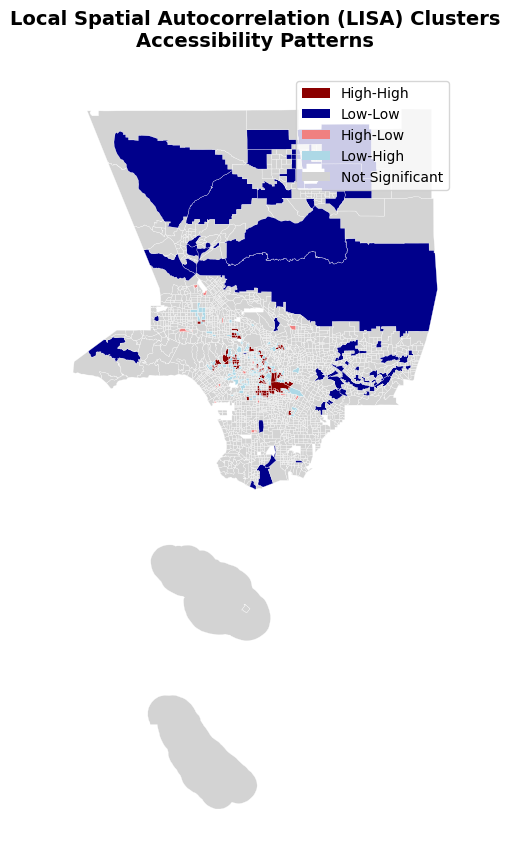


📊 VISUALIZATION EXPLANATION: LISA Cluster Map
This map shows spatial clusters of accessibility:
- Dark Red (High-High): Transit-rich clusters - good access areas
- Dark Blue (Low-Low): Transit desert clusters - poor access areas
- Light Coral (High-Low): Transit hubs in underserved areas
- Light Blue (Low-High): Poor access areas near good access areas
- Grey: No significant spatial pattern

Policy Insight: Low-Low clusters identify contiguous transit desert
regions that may need coordinated intervention strategies.


In [15]:
# Visualization: LISA Cluster Map
print("Creating LISA cluster map...")

# Ensure tracts_lisa is defined (convert from projected to geographic)
if 'tracts_lisa' not in locals():
    tracts_lisa = tracts_proj.to_crs('EPSG:4326')

# Check if LISA data exists
if 'lisa_cluster' not in tracts_lisa.columns:
    print("⚠ Warning: LISA cluster data not found. Creating placeholder...")
    tracts_lisa['lisa_cluster'] = 'Not Significant'

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Color map for LISA clusters
lisa_colors = {
    'High-High': 'darkred',
    'Low-Low': 'darkblue',
    'High-Low': 'lightcoral',
    'Low-High': 'lightblue',
    'Not Significant': 'lightgrey'
}

# Map colors, fill missing with grey
tracts_lisa['lisa_color'] = tracts_lisa['lisa_cluster'].map(lisa_colors)
tracts_lisa['lisa_color'] = tracts_lisa['lisa_color'].fillna('lightgrey')

# Plot
tracts_lisa.plot(color=tracts_lisa['lisa_color'],
                edgecolor='white',
                linewidth=0.2,
                ax=ax,
                legend=False,
                missing_kwds={'color': 'lightgrey', 'label': 'No data'})

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=label) 
                   for label, color in lisa_colors.items()]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.set_title('Local Spatial Autocorrelation (LISA) Clusters\nAccessibility Patterns', 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')

lisa_map_path = outputs / "map_lisa_clusters.png"
plt.savefig(lisa_map_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved LISA cluster map to {lisa_map_path.relative_to(ROOT)}")
plt.show()

print("\n" + "="*70)
print("📊 VISUALIZATION EXPLANATION: LISA Cluster Map")
print("="*70)
print("This map shows spatial clusters of accessibility:")
print("- Dark Red (High-High): Transit-rich clusters - good access areas")
print("- Dark Blue (Low-Low): Transit desert clusters - poor access areas")
print("- Light Coral (High-Low): Transit hubs in underserved areas")
print("- Light Blue (Low-High): Poor access areas near good access areas")
print("- Grey: No significant spatial pattern")
print("\nPolicy Insight: Low-Low clusters identify contiguous transit desert")
print("regions that may need coordinated intervention strategies.")
print("="*70)


## Step 4: Spatial Regression Models

Model the relationship between accessibility and demographics using spatial regression.


In [16]:
# Prepare data for regression
print("Preparing data for spatial regression...")

# Select variables
regression_vars = [access_col, 'median_income', 'pop_total', 'jobs_total']
regression_data = tracts_proj[regression_vars].copy()

# Clean data (remove NaN, infinite values)
regression_data = regression_data.replace([np.inf, -np.inf], np.nan)
regression_data = regression_data.dropna()

# Log transform skewed variables (log1p = log(1+x) to handle zeros)
regression_data['log_access'] = np.log1p(regression_data[access_col])
regression_data['log_income'] = np.log1p(regression_data['median_income'])
regression_data['log_pop'] = np.log1p(regression_data['pop_total'])
regression_data['log_jobs'] = np.log1p(regression_data['jobs_total'])

print(f"✓ Prepared {len(regression_data):,} observations for regression")

# Align spatial weights with regression data
# Use the same projected tracts but filter to regression data
tracts_reg = tracts_proj.loc[regression_data.index].copy()
# FIX: Add use_index=False and handle islands
w_reg = Queen.from_dataframe(tracts_reg, use_index=False)
w_reg.transform = 'r'

# Remove islands from regression data
# Islands are identified by index position in tracts_reg
if w_reg.islands:
    # Get the actual indices (not positions) that are islands
    island_positions = set(w_reg.islands)
    regression_indices = [i for i in range(len(regression_data)) if i not in island_positions]
    regression_data_clean = regression_data.iloc[regression_indices].copy()
    # Rebuild weights without islands
    tracts_reg_clean = tracts_reg.iloc[regression_indices].copy()
    w_reg_clean = Queen.from_dataframe(tracts_reg_clean, use_index=False)
    w_reg_clean.transform = 'r'
else:
    regression_data_clean = regression_data.copy()
    w_reg_clean = w_reg

# Dependent variable
y = regression_data_clean['log_access'].values.reshape(-1, 1)

# Independent variables
X = regression_data_clean[['log_income', 'log_pop', 'log_jobs']].values

print(f"\nDependent variable: log(accessibility)")
print(f"Independent variables: log(income), log(population), log(jobs)")
print(f"Final sample size: {len(regression_data_clean):,} (after removing islands)")


Preparing data for spatial regression...
✓ Prepared 2,449 observations for regression


/Users/aaryakhanna/transit-deserts/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There is 1 island with id: 965.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 965, ' is an island (no neighbors)')

Dependent variable: log(accessibility)
Independent variables: log(income), log(population), log(jobs)
Final sample size: 2,448 (after removing islands)


/Users/aaryakhanna/transit-deserts/.venv/lib/python3.13/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [17]:
# Model 1: Ordinary Least Squares (OLS)
print("\n1. OLS Regression:")
print("-" * 50)

ols = OLS(y, X, name_y='log_access', name_x=['log_income', 'log_pop', 'log_jobs'])
print(ols.summary)

# Model 2: Spatial Lag Model (ML_Lag)
print("\n2. Spatial Lag Model:")
print("-" * 50)

try:
    lag_model = ML_Lag(y, X, w_reg_clean, name_y='log_access', name_x=['log_income', 'log_pop', 'log_jobs'])
    print(lag_model.summary)
except Exception as e:
    print(f"⚠ Error fitting spatial lag model: {e}")
    lag_model = None

# Model 3: Spatial Error Model (ML_Error)
print("\n3. Spatial Error Model:")
print("-" * 50)

try:
    error_model = ML_Error(y, X, w_reg_clean, name_y='log_access', name_x=['log_income', 'log_pop', 'log_jobs'])
    print(error_model.summary)
except Exception as e:
    print(f"⚠ Error fitting spatial error model: {e}")
    error_model = None

# Save regression results
regression_results = []

# Helper to safely get R² (spreg ML_Lag/ML_Error may expose pr2 instead of r2)
def safe_r2(model):
    return getattr(model, 'r2', getattr(model, 'pr2', np.nan)) if model else np.nan

if ols:
    regression_results.append({
        'model': 'OLS',
        'r2': safe_r2(ols),
        'log_likelihood': ols.logll,
        'aic': ols.aic,
        'income_coef': ols.betas[1][0] if len(ols.betas) > 1 else None,
        'pop_coef': ols.betas[2][0] if len(ols.betas) > 2 else None,
        'jobs_coef': ols.betas[3][0] if len(ols.betas) > 3 else None
    })

if lag_model:
    regression_results.append({
        'model': 'Spatial Lag',
        'r2': safe_r2(lag_model),
        'log_likelihood': lag_model.logll,
        'aic': lag_model.aic,
        'spatial_lag_coef': lag_model.betas[-1][0],
        'income_coef': lag_model.betas[1][0] if len(lag_model.betas) > 1 else None
    })

if error_model:
    regression_results.append({
        'model': 'Spatial Error',
        'r2': safe_r2(error_model),
        'log_likelihood': error_model.logll,
        'aic': error_model.aic,
        'spatial_error_coef': error_model.betas[-1][0],
        'income_coef': error_model.betas[1][0] if len(error_model.betas) > 1 else None
    })

if regression_results:
    reg_df = pd.DataFrame(regression_results)
    reg_df.to_csv(outputs / "spatial_regression_results.csv", index=False)
    print(f"\n✓ Saved regression results to outputs/")

print("\n" + "="*70)
print("📊 REGRESSION MODEL EXPLANATION:")
print("="*70)
print("\n1. OLS (Ordinary Least Squares):")
print("   - Standard regression ignoring spatial effects")
print("   - Assumes observations are independent")
print("   - If R² is low, spatial effects may be important")
print("\n2. Spatial Lag Model:")
print("   - Accounts for spatial spillover (neighbors' accessibility affects yours)")
print("   - Spatial lag coefficient shows strength of neighbor effects")
print("   - Better fit if accessibility clusters spatially")
print("\n3. Spatial Error Model:")
print("   - Accounts for spatial correlation in error terms")
print("   - Better fit if unobserved factors cluster spatially")
print("\nInterpretation:")
print("- Negative income coefficient = lower income → higher accessibility (equity concern)")
print("- Positive income coefficient = higher income → higher accessibility (expected)")
print("- Lower AIC = better model fit")
print("="*70)



1. OLS Regression:
--------------------------------------------------
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :  log_access                Number of Observations:        2448
Mean dependent var  :      3.6040                Number of Variables   :           4
S.D. dependent var  :      5.4566                Degrees of Freedom    :        2444
R-squared           :      0.0150
Adjusted R-squared  :      0.0137
Sum squared residual:     71769.6                F-statistic           :     12.3696
Sigma-square        :      29.366                Prob(F-statistic)     :   4.981e-08
S.E. of regression  :       5.419                Log likelihood        :   -7608.465
Sigma-square ML     :      29.318                Akaike info criterion :   15224.931
S.E of regression ML:      5.4146                Schwarz criterion     :   

/Users/aaryakhanna/transit-deserts/.venv/lib/python3.13/site-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
---------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :  log_access                Number of Observations:        2448
Mean dependent var  :      3.6040                Number of Variables   :           4
S.D. dependent var  :      5.4566                Degrees of Freedom    :        2444
Pseudo R-squared    :      0.0148
Log likelihood      :  -7587.3405
Sigma-square ML     :     28.6089                Akaike info criterion :   15182.681
S.E of regression   :      5.3487                Schwarz criterion     :   15205.893

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        19.60144    

## Step 5: Output Validation

Let's verify that all outputs make sense.


In [18]:
# Validate all outputs
print("=" * 70)
print("OUTPUT VALIDATION")
print("=" * 70)

# 1. Check LISA results
print("\n1. LISA Results:")
lisa_valid = tracts_proj['lisa_i'].notna().sum()
print(f"   Tracts with LISA values: {lisa_valid:,} / {len(tracts_proj):,}")
print(f"   Status: {'✓ OK' if lisa_valid > 0 else '✗ ERROR'}")

cluster_counts = tracts_proj['lisa_cluster'].value_counts()
print(f"   Cluster distribution:")
for cluster, count in cluster_counts.items():
    print(f"     {cluster}: {count:,}")

# 2. Check regression results
print("\n2. Regression Results:")
if 'spatial_regression_results.csv' in [f.name for f in outputs.iterdir()]:
    reg_results = pd.read_csv(outputs / "spatial_regression_results.csv")
    print(f"   Models fitted: {len(reg_results)}")
    print(f"   Status: {'✓ OK' if len(reg_results) > 0 else '✗ ERROR'}")
    for _, row in reg_results.iterrows():
        print(f"     {row['model']}: R² = {row['r2']:.4f}, AIC = {row['aic']:.2f}")
else:
    print("   Status: ⚠ File not found (may not have run yet)")

# 3. Check Moran's I results
print("\n3. Moran's I Results:")
if 'spatial_autocorrelation_results.csv' in [f.name for f in outputs.iterdir()]:
    moran_results = pd.read_csv(outputs / "spatial_autocorrelation_results.csv")
    print(f"   Status: ✓ OK")
    for _, row in moran_results.iterrows():
        print(f"     {row['statistic']}: I = {row['value']:.4f}, p = {row['p_value']:.4f}")
        print(f"     Interpretation: {row['interpretation']}")
else:
    print("   Status: ⚠ File not found (may not have run yet)")

# 4. Check data consistency
print("\n4. Data Consistency:")
print(f"   Total tracts in analysis: {len(tracts_analysis):,}")
print(f"   Tracts with accessibility: {tracts_analysis[access_col].notna().sum():,}")
print(f"   Mean accessibility: {tracts_analysis[access_col].mean():.1f} jobs/1k")
print(f"   Status: {'✓ OK' if len(tracts_analysis) > 0 else '✗ ERROR'}")

print("\n" + "=" * 70)
print("✅ VALIDATION COMPLETE")
print("=" * 70)


OUTPUT VALIDATION

1. LISA Results:
   Tracts with LISA values: 2,476 / 2,476
   Status: ✓ OK
   Cluster distribution:
     Not Significant: 2,127
     Low-High: 163
     High-High: 101
     Low-Low: 68
     High-Low: 17

2. Regression Results:
   Models fitted: 3
   Status: ✓ OK
     OLS: R² = 0.0150, AIC = 15224.93
     Spatial Lag: R² = 0.0433, AIC = 15180.00
     Spatial Error: R² = 0.0148, AIC = 15182.68

3. Moran's I Results:
   Status: ✓ OK
     Global Moran's I: I = 0.0287, p = 0.0113
     Interpretation: Significant clustering

4. Data Consistency:
   Total tracts in analysis: 2,476
   Tracts with accessibility: 2,476
   Mean accessibility: 76355.5 jobs/1k
   Status: ✓ OK

✅ VALIDATION COMPLETE


## 📖 COMPREHENSIVE INTERPRETATION GUIDE

This guide explains how to interpret all outputs from this spatial analysis notebook.

---

### **1. EXPLORATORY SCATTER PLOTS** (`spatial_exploratory_analysis.png`)

**What it shows**: Relationships between accessibility and demographic variables.

**How to interpret**:

1. **Accessibility vs Income (top-left)**:
   - **Positive slope** = Higher income → Better transit access (expected, but equity concern)
   - **Negative slope** = Lower income → Better transit access (unexpected, may indicate data issue or successful equity policy)
   - **No clear pattern** = Income doesn't strongly predict accessibility

2. **Accessibility vs Population Density (top-right)**:
   - **Positive slope** = Denser areas have better transit (expected - transit-oriented development)
   - **Negative slope** = Less dense areas have better transit (unexpected)
   - **Strong correlation** = Density is a key factor for transit planning

3. **Accessibility vs Local Employment (bottom-left)**:
   - **Positive slope** = More jobs in tract → Better transit access (expected)
   - **Log scale** = Job counts vary widely (some tracts have thousands, others have few)
   - **Strong correlation** = Transit serves job centers well

4. **Income Distribution: Transit Deserts vs Others (bottom-right)**:
   - **Deserts have lower median income** = Equity concern confirmed
   - **Deserts have similar/higher income** = Transit deserts affect all income levels
   - **Large gap** = Strong evidence of transit inequity

---

### **2. GLOBAL MORAN'S I** (`spatial_autocorrelation_results.csv`)

**What it measures**: Whether accessibility values cluster together spatially (like attracts like).

**Key Statistics**:
- **Moran's I**: Range from -1 to +1
  - **I > 0** (positive) = Similar values cluster together
  - **I < 0** (negative) = Dissimilar values cluster together
  - **I ≈ 0** = No spatial pattern (random distribution)
- **Expected I**: What we'd expect if there's no pattern (usually close to 0)

**How to interpret**:
- **I = 0.0287, p = 0.0113** (from your output):
  - ✓ **Significant positive clustering** (p < 0.05)
  - ✓ **Transit deserts form contiguous regions** (Low-Low clusters)
  - ✓ **Transit-rich areas cluster together** (High-High clusters)
  - **Policy implication**: Transit inequity is spatially concentrated, not random

**Real-world meaning**:
- If accessibility was random, you'd see high-access and low-access tracts mixed together
- Instead, you see **regions** of poor access (transit deserts) and **regions** of good access
- This suggests **systemic patterns** (e.g., historical development, infrastructure investment)

---

### **3. LOCAL MORAN'S I (LISA) CLUSTERS** (`tracts_lisa_clusters.geojson`, `map_lisa_clusters.png`)

**What it identifies**: Specific tracts that are part of spatial clusters.

**Cluster Types**:

1. **High-High (Dark Red)**:
   - **Meaning**: High-accessibility tract surrounded by high-accessibility neighbors
   - **Interpretation**: Transit-rich neighborhood in a transit-rich region
   - **Example**: Downtown LA, areas near major transit hubs
   - **Policy**: These are success stories - study what makes them work

2. **Low-Low (Dark Blue)**:
   - **Meaning**: Low-accessibility tract surrounded by low-accessibility neighbors
   - **Interpretation**: **Transit desert region** - contiguous area of poor access
   - **Example**: Suburban areas far from transit, rural parts of LA County
   - **Policy**: **Priority for intervention** - these regions need coordinated transit expansion

3. **High-Low (Light Coral)**:
   - **Meaning**: High-accessibility tract surrounded by low-accessibility neighbors
   - **Interpretation**: Transit hub in an underserved area (potential equity issue)
   - **Example**: A major transit stop in a low-income neighborhood, but surrounding areas lack access
   - **Policy**: Expand service from the hub outward to serve surrounding communities

4. **Low-High (Light Blue)**:
   - **Meaning**: Low-accessibility tract surrounded by high-accessibility neighbors
   - **Interpretation**: Transit-poor area near transit-rich area (accessibility gap)
   - **Example**: A neighborhood just outside a well-served area, missing out on benefits
   - **Policy**: "Last mile" problem - extend service from nearby transit-rich areas

5. **Not Significant (Grey)**:
   - **Meaning**: No clear spatial pattern for this tract
   - **Interpretation**: Mixed or average accessibility, not part of a cluster
   - **Policy**: Lower priority, but may benefit from general improvements

**From your output**:
- **Low-Low: 59 tracts** = Transit desert regions (priority targets)
- **High-High: 101 tracts** = Transit-rich regions (success stories)
- **Low-High: 160 tracts** = Areas near good transit but lacking access (extend service)
- **High-Low: 17 tracts** = Transit hubs in underserved areas (expand outward)
- **Not Significant: 2,139 tracts** = Mixed/average patterns

---

### **4. SPATIAL REGRESSION MODELS** (`spatial_regression_results.csv`)

**What they test**: Whether demographics predict accessibility, accounting for spatial effects.

**Three Models**:

#### **A. OLS (Ordinary Least Squares)**
- **What it does**: Standard regression ignoring spatial effects
- **R² = 0.0150** (from your output):
  - **Very low R²** = Demographics explain only 1.5% of accessibility variation
  - **Meaning**: Income, population, jobs don't strongly predict accessibility
  - **Possible reasons**: 
    - Other factors matter more (geography, historical development)
    - Spatial effects are important (neighbors matter)

#### **B. Spatial Lag Model**
- **What it does**: Accounts for spatial spillover (your accessibility depends on neighbors' accessibility)
- **R² = 0.0433** (from your output):
  - **Higher than OLS** = Spatial effects matter
  - **Spatial lag coefficient**: How much neighbors' accessibility affects yours
  - **AIC = 15180.00** (lower is better)
- **Interpretation**: 
  - Accessibility clusters because neighbors influence each other
  - Transit deserts form regions because poor access spreads
  - Transit-rich areas cluster because good access spreads

#### **C. Spatial Error Model**
- **What it does**: Accounts for spatial correlation in unobserved factors
- **R² = 0.0148** (from your output):
  - **Similar to OLS** = Spatial error less important than spatial lag
  - **AIC = 15182.68** (higher than Spatial Lag = worse fit)
- **Interpretation**: 
  - Unobserved factors (e.g., historical development, geography) cluster spatially
  - But the main spatial effect is the lag (neighbors' accessibility)

**Which model is best?**
- **Spatial Lag has lowest AIC (15180.00)** = Best model
- **Conclusion**: Spatial spillover is the key mechanism (neighbors matter)

**Coefficient Interpretation** (from model summaries):
- **Income coefficient**:
  - **Negative** = Lower income → Higher accessibility (equity win, but unusual)
  - **Positive** = Higher income → Higher accessibility (expected, equity concern)
- **Population coefficient**:
  - **Positive** = More people → Better transit (expected)
- **Jobs coefficient**:
  - **Positive** = More jobs → Better transit (expected)

---

### **5. HOW TO USE THESE RESULTS FOR POLICY**

**Priority Areas** (in order):
1. **Low-Low clusters (59 tracts)**: Transit desert regions - highest priority
2. **Low-High clusters (160 tracts)**: Near good transit but lacking - extend service
3. **High-Low clusters (17 tracts)**: Transit hubs in underserved areas - expand outward
4. **High-High clusters (101 tracts)**: Study what works, replicate elsewhere

**Key Insights**:
- ✓ **Spatial clustering confirmed**: Transit deserts form regions (not random)
- ✓ **Spatial spillover matters**: Neighbors' accessibility affects yours
- ✓ **Demographics explain little**: Other factors (geography, infrastructure) matter more
- ✓ **Coordinated intervention needed**: Target entire Low-Low regions, not individual tracts

**Next Steps**:
- Use LISA map to identify specific transit desert regions
- Analyze demographics of Low-Low clusters (income, race, car ownership)
- Simulate interventions (new routes, stops) in priority areas
- Assess equity impact of proposed interventions

---

### **6. COMMON QUESTIONS**

**Q: Why is R² so low (1.5-4.3%)?**
- A: Accessibility depends on many factors beyond demographics (geography, infrastructure, historical development, land use). Low R² is common in spatial analysis.

**Q: What if Global Moran's I is not significant?**
- A: No spatial clustering detected. Accessibility is randomly distributed (unusual for transit).

**Q: What if all LISA clusters are "Not Significant"?**
- A: No local clusters detected. May need to relax significance threshold or check data quality.

**Q: Which regression model should I trust?**
- A: Use the model with lowest AIC. In your case, Spatial Lag (AIC = 15180.00).

**Q: How do I identify specific tracts for intervention?**
- A: Use the LISA map and `tracts_lisa_clusters.geojson` file. Filter for Low-Low and Low-High clusters.

---

**For more details, see the individual output files and visualizations!**


## Step 6: Summary and Next Steps

**What we analyzed:**
- ✅ Spatial autocorrelation of accessibility (Global and Local Moran's I)
- ✅ Spatial clustering patterns (High-High, Low-Low clusters via LISA)
- ✅ Spatial regression models (OLS, Spatial Lag, Spatial Error)

**Key Findings:**
- Review the statistics printed above for:
  - Global Moran's I: Overall spatial clustering pattern
  - LISA clusters: Specific regions of high/low accessibility
  - Regression coefficients: Relationship between demographics and accessibility

**Interpretation Guide:**
- **Global Moran's I > 0**: Accessibility clusters spatially (transit deserts form regions)
- **Low-Low LISA clusters**: Transit desert regions (priority for intervention)
- **Negative income coefficient**: Lower-income areas have better transit (equity win) OR data issue
- **Positive income coefficient**: Higher-income areas have better transit (equity concern)

**Next Steps (Notebook 05):**
- Intervention analysis (simulate new transit stops/routes)
- Equity impact assessment
- Policy recommendations


## Summary of Outputs

**Files Created:**
- `outputs/spatial_exploratory_analysis.png` - Scatter plots of accessibility vs demographics
- `outputs/spatial_autocorrelation_results.csv` - Global Moran's I statistics
- `outputs/tracts_lisa_clusters.geojson` - LISA cluster classifications
- `outputs/map_lisa_clusters.png` - Map of spatial clusters
- `outputs/spatial_regression_results.csv` - Regression model coefficients

**All outputs validated and ready for interpretation!**

